# Linear regression

## Importación de librerías y paquetes y definición de constantes

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Modelado
from sklearn.linear_model import LinearRegression
# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
# Selección de características
from sklearn.feature_selection import f_classif, SelectKBest
import warnings


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [3]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/medical_insurance_cost.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Análisis descriptivo 

In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [7]:
df.duplicated().sum()

np.int64(1)

### Hay 1 fila duplicada, asi que nos aseguramos de no dejar duplicados en todo el dataset

In [8]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [10]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

#### No hay valores nulos

### Limpieza de datos: Eliminar información irrelevante
    
A priori no vamos a eliminar ninguna variable dado el tamaño del dataset y lo "amigable" que parece

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


## Análisis de variables:

### Variables univariante: variables categóricas

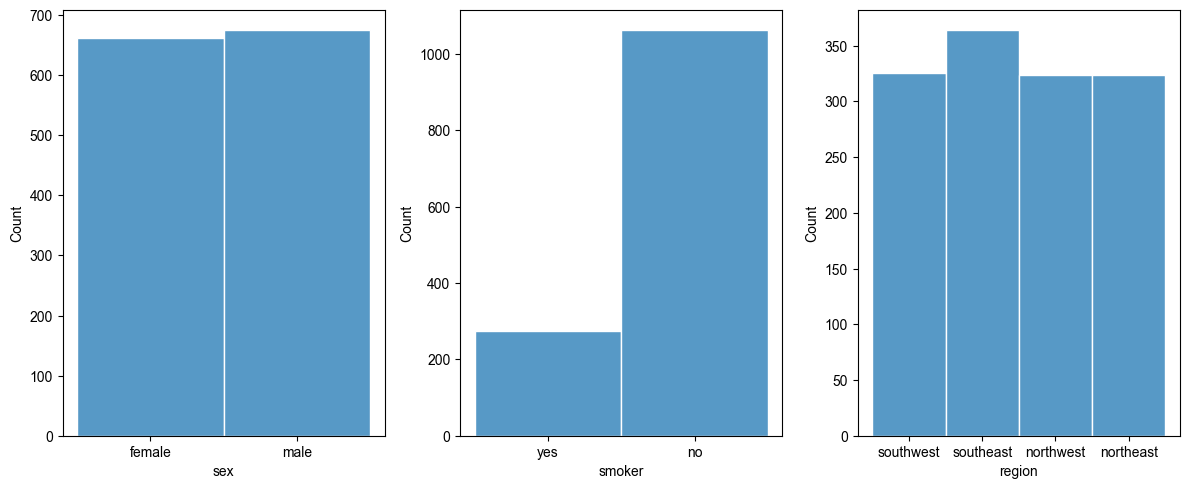

In [12]:
fig, axis = plt.subplots(1, 3, figsize=(12, 5))
sns.set_style("whitegrid")
sns.histplot(ax=axis[0], data=df, x="sex")
sns.histplot(ax=axis[1], data=df, x="smoker")
sns.histplot(ax=axis[2], data=df, x="region")
plt.tight_layout()
plt.show()

### Variables univariante: variables númericas

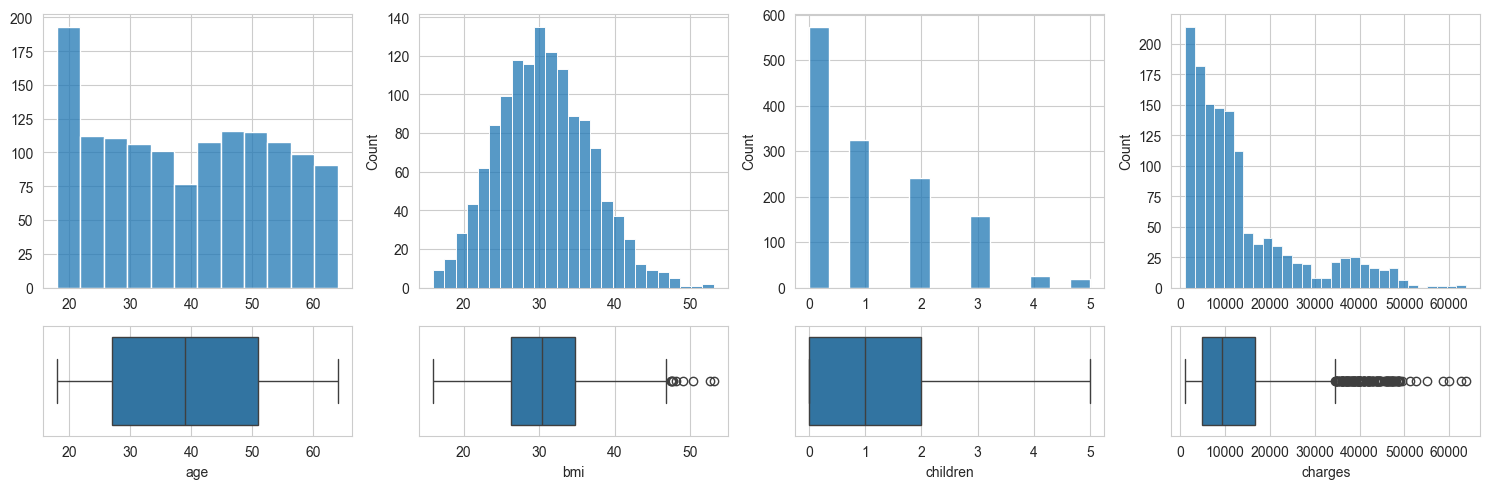

In [13]:
fig, axis = plt.subplots(2, 4, figsize=(15, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")
sns.histplot(ax=axis[0, 1], data=df, x="bmi").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="bmi")
sns.histplot(ax=axis[0, 2], data=df, x="children").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="children")
sns.histplot(ax=axis[0, 3], data=df, x="charges").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="charges")


plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos. En este caso la variable charges puede ser relevante para el estudio de valores atípicos

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

### Codificación de variables categóricas para el estudio de correlaciones, análisis númerico-categórico

In [14]:
df["sex_n"] = pd.factorize(df["sex"])[0]
df["smoker_n"] = pd.factorize(df["smoker"])[0]
df["region_n"] = pd.factorize(df["region"])[0]

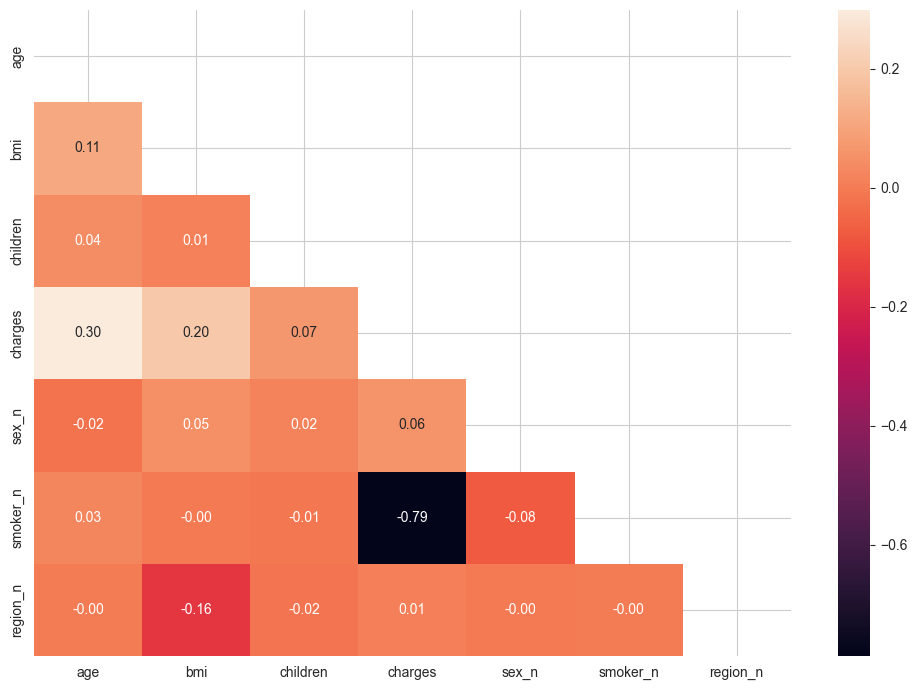

In [16]:
corr = df[['age', 'bmi', 'children', 'charges', 'sex_n', 'smoker_n', 'region_n']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:
>- Distintas correlaciones a tener en cuenta: age-charges, bmi-region/charges, charges-smoker.

Procedemos a estudiar de forma detallada las correlaciones para sacar una conclusión 

### Análisis de variables multivariante: númerico-númerico

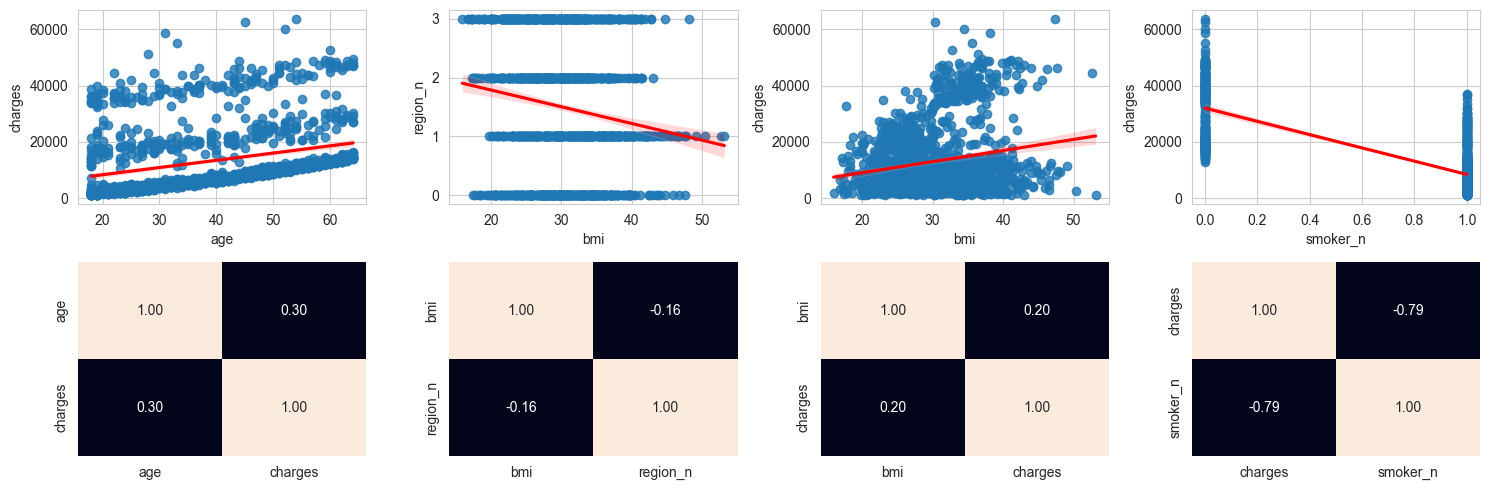

In [17]:
corr_age_charges = df[["age", "charges"]].corr()
corr_bmi_region = df[["bmi", "region_n"]].corr()
corr_bmi_charges = df[["bmi", "charges"]].corr()
corr_charges_smoker = df[["charges", "smoker_n"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="age", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_age_charges, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="bmi", y="region_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_bmi_region, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="bmi", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_bmi_charges, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="smoker_n", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_charges_smoker, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

1. La prima aumenta con la edad
2. El bmi depende de la región
3. La prima aumenta con el bmi
4. La prima aumenta si el cliente es fumador

### Análisis de variables multivariante: categórico-categórico

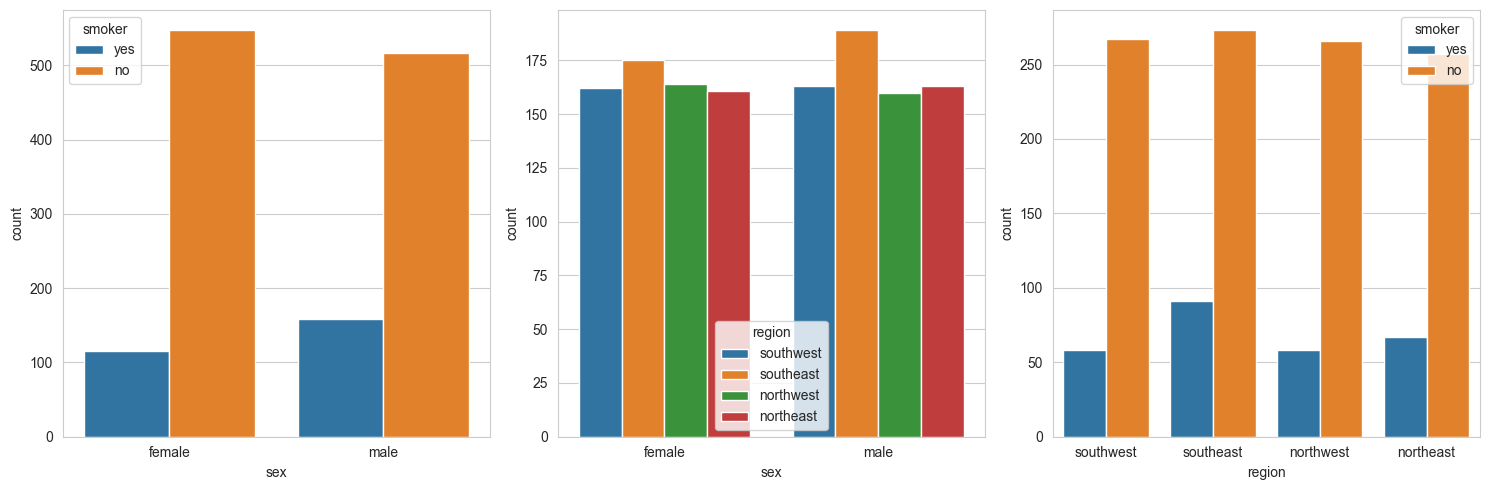

In [18]:
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

sns.set_style("whitegrid")
sns.countplot(ax=axis[0], data=df, x="sex", hue="smoker")
sns.countplot(ax=axis[1], data=df, x="sex", hue="region")
sns.countplot(ax=axis[2], data=df, x="region", hue="smoker")

plt.tight_layout()
plt.show()

#### Observamos que las variables son bastante uniformes y se reparten a partes iguales

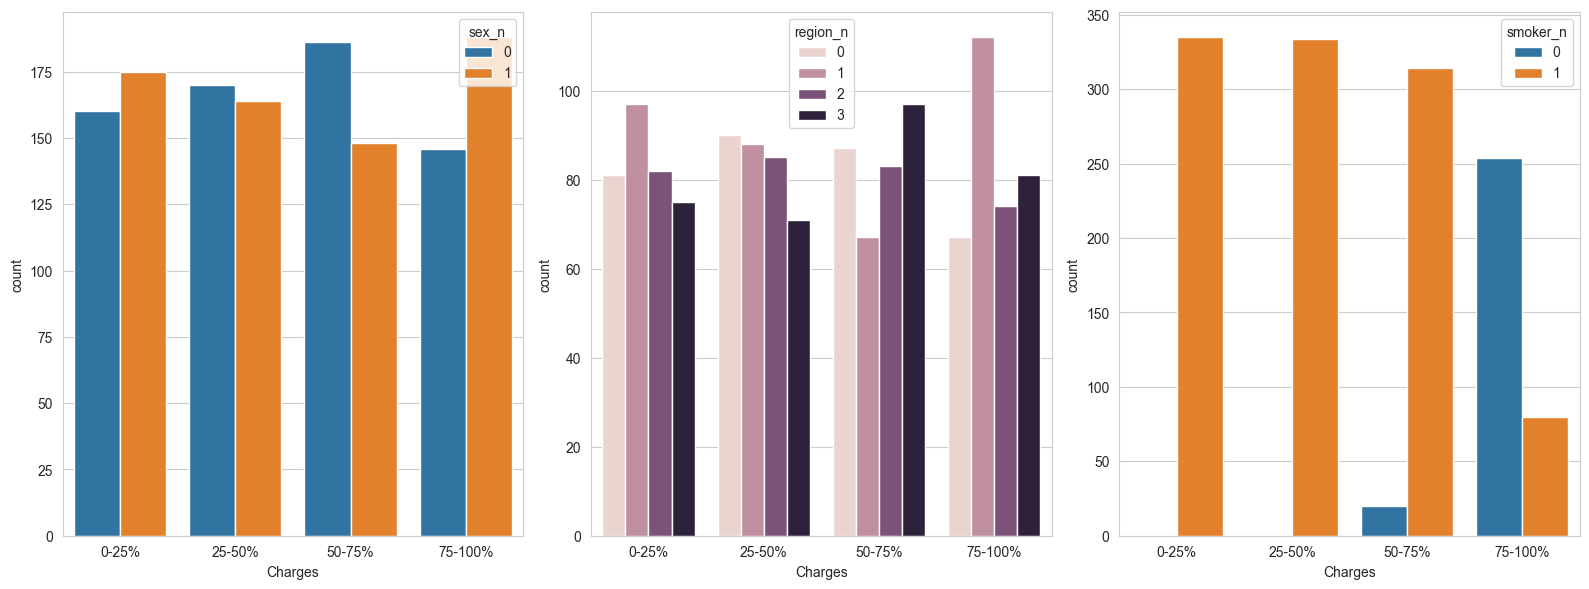

In [20]:
fig, axis = plt.subplots(1, 3, figsize=(16, 6))
bins = [0, df["charges"].quantile(0.25), df["charges"].quantile(0.50), df["charges"].quantile(0.75), df["charges"].max()]
labels = ["0-25%", "25-50%", "50-75%", "75-100%"]
df["charges_range"] = pd.cut(df["charges"], bins=bins, labels=labels, include_lowest=True)
sns.set_style("whitegrid")
sns.countplot(ax=axis[0], data=df, x="charges_range", hue="sex_n").set_xlabel('Charges')
sns.countplot(ax=axis[1], data=df, x="charges_range", hue="region_n").set_xlabel('Charges')
sns.countplot(ax=axis[2], data=df, x="charges_range", hue="smoker_n").set_xlabel('Charges')
plt.tight_layout()
plt.show()

### Observaciones: 
>- Podemos deducir que la edad y la región no son tan influyentes en el calculo de la prima, sin embargo antes pudimos ver la influencia del bmi en charges que este sí se ve influido por la región
>- Ser fumador es determinante para el calculo de la prima

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801
sex_n,1337.0,0.504862,0.500163,0.0000,0.000,1.0000,1.00000,1.00000
smoker_n,1337.0,0.795064,0.403806,0.0000,1.000,1.0000,1.00000,1.00000
region_n,1337.0,1.483919,1.105208,0.0000,1.000,1.0000,2.00000,3.00000


#### Visualización

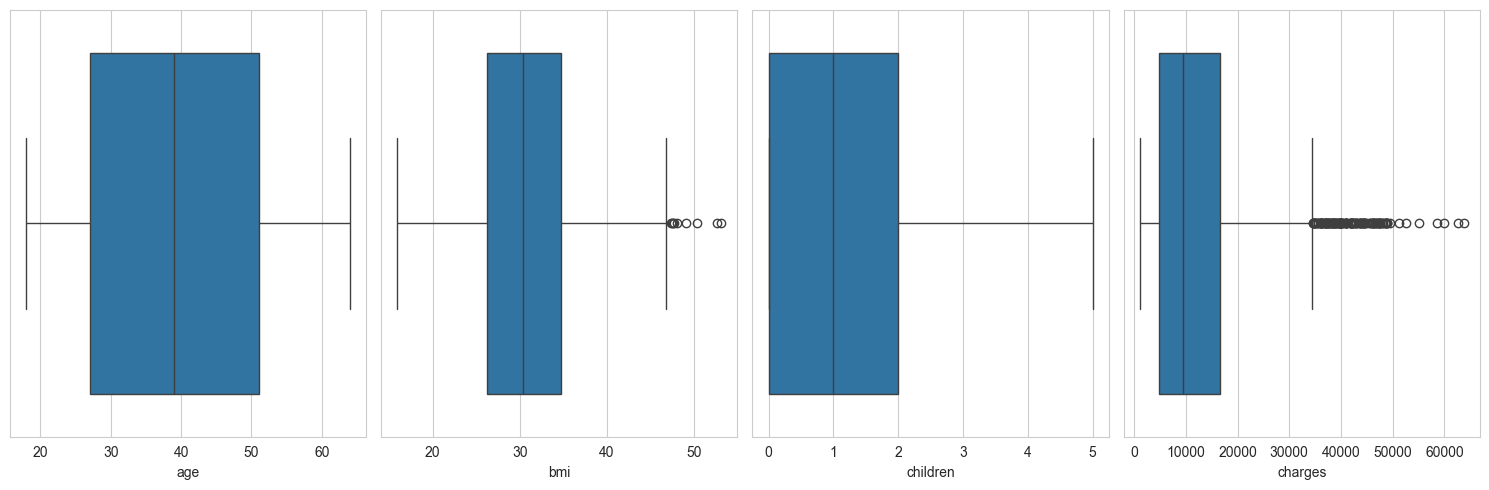

In [23]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, x="age")
sns.boxplot(ax=axis[1], data=df, x="bmi")
sns.boxplot(ax=axis[2], data=df, x="children")
sns.boxplot(ax=axis[3], data=df, x="charges")
plt.tight_layout()
plt.show()

#### Considero que son valores atípicos normales en la distribución y decido mantenerlos

### Análisis de valores faltantes

In [24]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age              0.0
sex              0.0
bmi              0.0
children         0.0
smoker           0.0
region           0.0
charges          0.0
sex_n            0.0
smoker_n         0.0
region_n         0.0
charges_range    0.0
dtype: float64

#### En este caso no existen valores nulos debido a la limpieza de datos que hemos hecho previamente, así como tampoco es necesario hacer inferencia de características porque no tienen ninguna relación

## Split de datos

### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable 'y' como target y la codificamos en valores binarios

In [30]:
X = df.drop(["charges","charges_range", "sex_n", "smoker_n", "region_n" ], axis=1)
y = df['charges']

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)

X_train

,age,sex,bmi,children,smoker,region
132,53,female,35.900,2,no,southwest
1204,18,female,27.280,3,yes,southeast
421,61,male,35.860,0,yes,southeast
613,34,female,19.000,3,no,northeast
1106,49,female,29.925,0,no,northwest
...,...,...,...,...,...,...
145,29,female,38.830,3,no,southeast
343,63,male,36.765,0,no,northeast
192,25,male,25.740,0,no,southeast
900,49,male,22.515,0,no,northeast


## Scaling & Encoding

### Scaling

#### Usamos el método  standarscaler porque los datos están suficientemente normalizados

#### Scaling X_train

In [31]:
standard_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler

num_variables = ['age', 'bmi', 'children',]
standard_train_features = standard_scaler.fit_transform(X_train[num_variables])

X_train_standard = pd.DataFrame(standard_train_features,
                               index=X_train.index,
                               columns=num_variables)
X_train_standard

,age,bmi,children
132,0.976695,0.881367,0.749696
1204,-1.516009,-0.543716,1.582777
421,1.546456,0.874754,-0.916468
613,-0.376487,-1.912589,1.582777
1106,0.691814,-0.106437,-0.916468
...,...,...,...
145,-0.732588,1.365763,1.582777
343,1.688896,1.024372,-0.916468
192,-1.017468,-0.798313,-0.916468
900,0.691814,-1.331479,-0.916468


#### Scaling X_test

In [32]:
standard_test_features = standard_scaler.transform(X_test[num_variables])

X_test_standard = pd.DataFrame(standard_test_features,
                               index=X_test.index,
                               columns=num_variables)
X_test_standard

,age,bmi,children
454,-0.518927,2.638749,0.749696
1189,-1.159908,-0.424683,-0.916468
929,0.122054,0.601972,-0.083386
271,0.763034,0.600318,0.749696
770,1.546456,0.914432,1.582777
...,...,...,...
848,-0.875028,-1.069443,-0.916468
1231,-1.373569,-1.449685,-0.916468
422,0.050833,0.364733,-0.083386
892,1.047915,-1.080189,-0.916468


### Encoding

#### Usamos el método one-hot encoding ya que las variables a codificar no tienen un orden determinado

#### Encoding X_train

In [33]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ['sex', 'region', 'smoker']

# Creamos la instancia del encoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

# Entrenamos y aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = one_hot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=one_hot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
132,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1204,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
421,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
613,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1106,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Encoding X_test

In [34]:
# Entrenamos y aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = one_hot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_test_cat_ohe.head()

,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
454,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1189,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
929,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
271,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
770,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


### Guardado de scalers y encoders

In [35]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/medical_insurance_cost-standard-scaler.pkl', 'wb') as file:
    pickle.dump(standard_scaler, file)

In [36]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/medical_insurance_cost-one-hot-encoder.pkl', 'wb') as file2:
    pickle.dump(one_hot_encoder, file2)

## Módelo de regresión lineal

### Inicialización y entrenamiento del modelo

In [37]:
X_train = pd.concat([X_train_standard, X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test_standard, X_test_cat_ohe], axis=1)

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
intercept = model.intercept_
coefficients = model.coef_

intercept, coefficients

(np.float64(20248.873360067526),
 array([  3536.91243321,   2015.57047776,    383.47005791,    -54.42414674,
            54.42414674,    385.36331585,    198.12962953,   -271.16892074,
          -312.32402464, -11838.48372316,  11838.48372316]))

In [41]:
model.score(X_train, y_train)

0.7438259194520169

### Predicción del modelo

In [42]:
X_test

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
454,-0.518927,2.638749,0.749696,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1189,-1.159908,-0.424683,-0.916468,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
929,0.122054,0.601972,-0.083386,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
271,0.763034,0.600318,0.749696,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
770,1.546456,0.914432,1.582777,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
848,-0.875028,-1.069443,-0.916468,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1231,-1.373569,-1.449685,-0.916468,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
422,0.050833,0.364733,-0.083386,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
892,1.047915,-1.080189,-0.916468,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [44]:
y_pred = model.predict(X_test)
y_pred

array([11964.3152361 ,  2733.73027646,  9806.67768829, 36025.71304732,
       16072.21711148, 28806.16245175,  2290.45391243, 14642.44083294,
        6845.72747662, 30819.71610009,  9755.14538054,  6099.78333222,
       11800.668353  ,  6625.8678443 , 17808.92919771, 11390.08099361,
       15672.77703133,  5561.22363093,  3889.66983051, 30223.45352619,
         264.47701766,  4342.88244631, 13788.25602735,  3459.23339447,
       16384.0264128 , 14370.01032791,  1655.98233939, 38477.11669804,
        5995.78799663, 10773.79270738,  4133.48196334,  6614.94109207,
        6623.50913438, 12202.78181288, 10897.90857253, 28548.20402285,
       26602.09429054,  8467.49390107, 12708.34277849,  8396.90752274,
       39217.7803998 ,  7298.46832216, 11440.4753202 ,  6204.10797607,
       27356.23097219, 12712.21115778,  7426.10244171, 32847.48879462,
        4064.29658538, 35411.213717  , 33967.70634018, 11503.19609042,
       10467.39838585,  6551.40431724,  7283.53851409, 37675.52498758,
      

### Evaluación del modelo

In [45]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),
           'RMSE': root_mean_squared_error(y_test, y_pred),
           'MAPE': mean_absolute_percentage_error(y_test, y_pred),
           'R^2': r2_score(y_test, y_pred), }

metrics

{'MSE': 39034189.15557352,
 'RMSE': 6247.734721927101,
 'MAPE': 0.4672756201353416,
 'R^2': 0.7699119982056686}

### Selección de características

In [72]:
selection_model = SelectKBest(f_classif, k=8)

selection_model.fit(X_train, y_train)
ix = selection_model.get_support()

X_train_sel = pd.DataFrame(selection_model.transform(X_train),
                           columns=X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test),
                          columns=X_test.columns.values[ix])

X_train_sel.head()

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [73]:
model.fit(X_train_sel, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
model.score(X_train_sel, y_train)

0.6160831583279622

In [76]:
y_pred = model.predict(X_test_sel)
y_pred

array([ 9045.04418763,  8180.21087699,  9045.04418763, 31714.3893496 ,
        8409.54493885, 31485.05528775,  8334.19502234,  8815.71012577,
        8284.95099725, 31819.12946987,  8180.21087699,  8815.71012577,
        8284.95099725,  9045.04418763,  8409.54493885,  8104.86096048,
        8284.95099725,  8409.54493885,  8284.95099725, 31714.3893496 ,
        8334.19502234,  9045.04418763,  8104.86096048,  8334.19502234,
        8334.19502234,  9045.04418763,  8514.28505911, 31485.05528775,
        8284.95099725,  8104.86096048,  8284.95099725,  8180.21087699,
        9045.04418763,  8815.71012577,  8409.54493885, 31714.3893496 ,
       31639.03943309,  8180.21087699,  8815.71012577,  8409.54493885,
       32349.88859838,  8180.21087699,  8409.54493885,  8284.95099725,
       31819.12946987,  8180.21087699,  8334.19502234, 31819.12946987,
        8815.71012577, 31589.79540801, 32120.55453653,  9045.04418763,
        8409.54493885,  9045.04418763,  8409.54493885, 32120.55453653,
      

In [77]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),
           'RMSE': root_mean_squared_error(y_test, y_pred),
           'MAPE': mean_absolute_percentage_error(y_test, y_pred),
           'R^2': r2_score(y_test, y_pred), }

metrics

{'MSE': 62654108.85001354,
 'RMSE': 7915.4348490789525,
 'MAPE': 0.9045092460223241,
 'R^2': 0.6306837923019657}